# Reinforcement Learning Reward Design Exercise

[![Google Colab](https://img.shields.io/badge/Google%20Colab-F9AB00?logo=googlecolab&logoColor=fff&style=for-the-badge)](https://colab.research.google.com/drive/1SAi1mqlKsceHQ0nLfddgx9zEOxw0vW4k?usp=drive_link)

In this exercise, you will be applying the reinforcement learning and traffic management concepts explained during the lectures. We will be focusing on the reward function and how designers aim to guide RL agents towards learning an optimal policy.

Here, we use a small 4-way intersection with a Deep Q-Network (DQN) traffic signal controller. The scenario is visualised below, along with an outline of the controller's state/action setup. An empty cell has been left for the implementation of the reward function itself, along with some instructions on how to fetch data from the simulation.

This notebook can be run locally, but it is recommeded to use [Google Colab](https://colab.research.google.com/drive/1SAi1mqlKsceHQ0nLfddgx9zEOxw0vW4k?usp=drive_link). In this case, create your own copy before starting your work ('_file_' > '_Save a copy in Drive_').


---
## Objectives

1. Choose a demand profile in the '_Defining the Scenario_' cell.
2. Implement a reward function design in the cell below.
3. Train your agent and observe performance using the visualisations at the bottom of the notebook.
4. **Try to produce the lowest overall average delay or travel time compared to the other groups!**

Extra objectives (optional):
1. Change the OD-demand values or create your own profile to see how this impacts performance.
2. Test different hyperparameter values.

----
## Traffic Simulator
The scenario is simulated using UXsim:
  - Documentation: https://toruseo.jp/UXsim/docs/index.html
  - This exercise is based on [this DQN example](https://toruseo.jp/UXsim/docs/notebooks/demo_notebook_03en_pytorch.html).


## Initial Setup & Imports

In [1]:
%%capture
%matplotlib inline
!pip install uxsim matplotlib gymnasium scipy torch;

In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

import gymnasium as gym
import math
import random
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count
from scipy.optimize import minimize
from IPython.display import clear_output

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from uxsim import *
import random
import itertools
import copy

global log_rewards
global log_states
global log_epi_average_delay

## Defining the Scenario

Choose a demand profile to test your model on. To change either the demand profile, length of each episode or control interval, update the variables below and rerun the cell.

Available profiles are:
  - `"default"`: Base scenario with some congestion and fairly even demand across all links.
  - `"heavy_demand"`: More heavily congested variant of the base scenario.
  - `"unbalanced"`: A scenario with high demand from the west of the network. The demand from all other directions is the same.
  - `"random"`: Use entirely random demand from all directions. Re-run the cell to regenerate demand. The same OD demand generated below is used throughout the rest of the notebook in training/evaluation.

In [3]:
demand_profile = "default"
scenario_len, control_interval = 3600, 10 # seconds

match demand_profile:
    case "default":
                    #  N    E    S    w
        od_demand = [[ 0,  400, 500, 400], # N
                     [400,  0,  400, 550], # E
                     [500, 400,  0,  400], # S
                     [400, 550, 400,  0 ]] # W

    case "heavy_demand":
                    #  N    E    S    w
        od_demand = [[ 0,  450, 550, 550], # N
                     [450,  0,  450, 600], # E
                     [550, 450,  0,  450], # S
                     [450, 600, 450,  0 ]] # W

    case "unbalanced":
                    #  N    E    S    w
        od_demand = [[  0, 400, 400, 400], # N
                     [400,   0, 400, 400], # E
                     [400, 400,   0, 400], # S
                     [550, 550, 550,   0]] # W

    case "random":
        od_demand = [[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]]
        for i in range(4):
            for j in range(4):
                if i == j: od_demand[i][j] = 0
                else: od_demand[i][j] = random.randint(200, 700)

    case _: raise(ValueError, "Unknown demand_profile")

In [4]:
def create_world(seed=None):
    W = World(
        name="",
        deltan=5,
        tmax=scenario_len,
        print_mode=0, save_mode=0, show_mode=1,
        random_seed=seed,
        duo_update_time=600
    )
    random.seed(seed)

    # Network definition
    tl = W.addNode("tl", 0, 0, signal=[60,60,60,60])
    north = W.addNode("north", 0, 1)
    east = W.addNode("east", 1, 0)
    south = W.addNode("south", 0, -1)
    west = W.addNode("west", -1, 0)
    all_links, origins = {}, [north, east, south, west]

    for link_idx, (org, dest) in enumerate([(north, tl), (east, tl), (south, tl), (west, tl)]):
        if org.name not in all_links: all_links[org.name] = {}
        if dest.name not in all_links: all_links[dest.name] = {}

        all_links[org.name][dest.name] = W.addLink(f"{org.name}_{dest.name}", org, dest, length=500, free_flow_speed=10, jam_density=0.2, signal_group=link_idx)
        all_links[dest.name][org.name] = W.addLink(f"{dest.name}_{org.name}", dest, org, length=500, free_flow_speed=10, jam_density=0.2, signal_group=link_idx)

    # Add demand
    for origin, demand_vals in zip(origins, od_demand):
        for idx, demand in enumerate(demand_vals):
            if demand == 0: continue
            for t in range(0, scenario_len, 30):
                W.adddemand(origin, origins[idx], t, t+30, random.uniform(0, demand*2/3600))

    return W, tl, all_links

## Base Scenario

Below is a diagram showing the scenario's layout (with object IDs) and an animation of the scenario with a base fixed time control. Each scenario lasts 1 hour.

The DQN controls the traffic signal at the node "_tl_," with each other node labelled using "_north_," "_east_", "_south_" and "_west_".

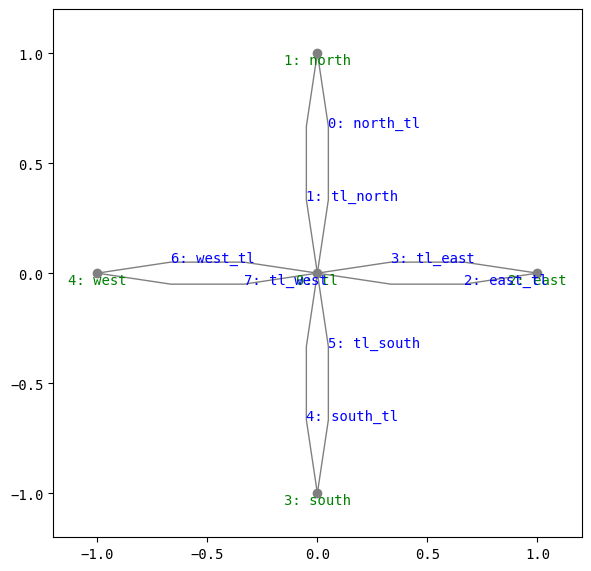

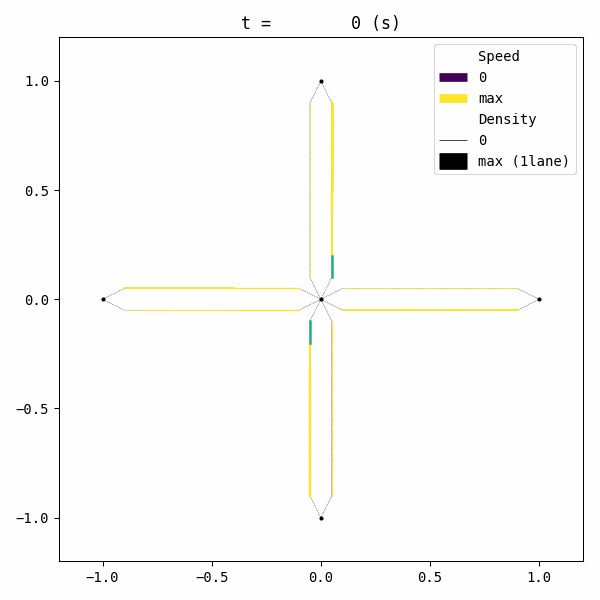

In [5]:
W, _, _ = create_world(seed=1)
W.show_network()
W.exec_simulation()

gif_loc = f"{demand_profile}_scenario.gif"
if not os.path.exists(gif_loc) or demand_profile == 'random':
    W.analyzer.network_anim(detailed=1, figsize=(6,6), network_font_size=0, file_name=gif_loc)

from IPython.display import display, Image
with open(gif_loc, "rb") as f: display(Image(data=f.read(), format='png'))

## Defining the RL Agent

In [6]:
class TrafficSim(gym.Env):
    def __init__(self):

        # Define 4 continuous state variables
        self.n_state = 4
        low = np.array([0 for i in range(self.n_state)])
        high = np.array([100 for i in range(self.n_state)])
        self.observation_space = gym.spaces.Box(low=low, high=high)

        # Define 4 discrete actions
        self.n_action = 4
        self.action_space = gym.spaces.Discrete(self.n_action)

        self.reset()

    def reset(self, seed=None):
        """
        reset the env
        """

        # Create new scenario for the current episode
        self.W, self.tl, self.all_links = create_world(seed)
        self.INLINKS = list(self.tl.inlinks.values())

        # Get initial observation
        observation = np.array([0 for i in range(self.n_state)])

        # Reset state/reward logs
        self.log_state = []
        self.log_reward = []

        return observation, None

    def comp_state(self):
        """
        Compute the current state
        """
        vehicles_per_links = {}
        for l in self.INLINKS:
            vehicles_per_links[l] = l.num_vehicles_queue #l.num_vehicles_queue = the number of vehicles queuing in link l
        return list(vehicles_per_links.values())

    def comp_n_veh_queue(self):
        return sum(self.comp_state())

    def comp_reward(self):
        raise NotImplementedError("Implement your reward function in the cell below!")

    def step(self, action_index):
        """
        Complete the next cycle of the training loop
        """

        # Decode action and update lights
        binstr = f"{action_index:04b}"
        self.tl.signal_phase = int(action_index)
        self.tl.signal_t = 0

        # Execute simulation for `control_interval` seconds
        if self.W.check_simulation_ongoing():
            self.W.exec_simulation(duration_t=control_interval)

        # Observe the environment state
        observation = np.array(self.comp_state())

        # Compute agent reward (using below function!)
        reward = self.comp_reward()

        # Check if simulation is ending early
        done = False
        if self.W.check_simulation_ongoing() == False:
            done = True

        # Log state & rewards
        self.log_state.append(observation)
        log_rewards[-1].append(reward)

        return observation, reward, done, {}, None


# DQN Agent Setup

The RL agent is a Deep Q-Network with the following setup:

  - **State:** The agent has 4 continuous state variables, which are the number of vehicles queuing on each link entering the intersection.
  - **Action:** There are 4 possible actions for the agent, which represent giving green time to each link.
  - **Reward:** You decide!

As a result, the agent learns a policy it can use to decide which link is given green for the following control interval (lasting 10s). Through training, the agent learns to make this decision in a way that maximises the return it receives from the reward function you implement.

----
### Implementing the Reward Function

Each link is stored in a dictionary `self.all_links` and can be accessed using `self.all_links[ORIGIN_NODE][DESTINATION_NODE]`. The available measures from each link are:
  - `speed`
  - `density`
  - `flow`
  - `num_vehicles`
  - `num_vehicles_queue`
  - `free_flow_speed`
  - `jam_density`
  - `capacity_in`
  - `capacity_out`

For example, the average speed on a link/all links can be fetched as below:

```python
link_speed = self.all_links['south']['tl'].speed

org_nodes = ['north', 'east', 'south', 'west']
incoming_link_speed = sum(self.all_links[org]['tl'].speed for org in org_nodes) / 4
```

In [7]:
def comp_reward(self):

    # Your code here!

    return 0

# Do not delete
TrafficSim.comp_reward = comp_reward

## Defining the Deep Q-Network

For more information on DQNs:

1. V. Mnih, K. Kavukcuoglu, D. Silver, A. Graves, I. Antonoglou, D. Wierstra, and M. A.
Riedmiller, “[_Playing Atari with Deep Reinforcement Learning_](https://arxiv.org/pdf/1312.05602),” 2013. arXiv: 1312.5602.
2. Y. Huang, “[_Deep Q-Networks_](https://link.springer.com/chapter/10.1007/978-981-15-4095-0_4),” in Deep Reinforcement Learning: Fundamentals, Research
and Applications (H. Dong, Z. Ding, and S. Zhang, eds.), pp. 135–160, Springer
Singapore, 2020.

In [8]:
env = TrafficSim()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))

class ReplayMemory(object):
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

class DQN(nn.Module):
    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        n_neurals = 64
        n_layers = 3
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(n_observations, n_neurals))
        for i in range(n_layers):
            self.layers.append(nn.Linear(n_neurals, n_neurals))
        self.layer_last = nn.Linear(n_neurals, n_actions)

    # Called with either one element to determine next action, or a batch during optimization. Returns tensor([[left0exp,right0exp]...]).
    def forward(self, x):
        for layer in self.layers:
            x = F.relu(layer(x))
        return self.layer_last(x)

def select_action(state):
    global steps_done
    sample = random.random()
    eps_threshold = EPS_END + (EPS_START - EPS_END) * math.exp(-1. * steps_done / EPS_DECAY)
    steps_done += 1
    if sample > eps_threshold:
        with torch.no_grad():
            # t.max(1) will return the largest column value of each row. second column on max result is index of where max element was found, so we pick action with the larger expected reward.
            return policy_net(state).max(1)[1].view(1, 1)
    else:
        return torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)

def optimize_model():
    if len(memory) < BATCH_SIZE:
        return
    transitions = memory.sample(BATCH_SIZE)
    # Transpose the batch (see https://stackoverflow.com/a/19343/3343043 for detailed explanation). This converts batch-array of Transitions to Transition of batch-arrays.
    batch = Transition(*zip(*transitions))

    # Compute a mask of non-final states and concatenate the batch elements (a final state would've been the one after which simulation ended)
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                          batch.next_state)), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state
                                                if s is not None])
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    # Compute Q(s_t, a) - the model computes Q(s_t), then we select the columns of actions taken. These are the actions which would've been taken for each batch state according to policy_net
    state_action_values = policy_net(state_batch).gather(1, action_batch)

    # Compute V(s_{t+1}) for all next states.
    # Expected values of actions for non_final_next_states are computed based on the "older" target_net; selecting their best reward with max(1)[0].
    # This is merged based on the mask, such that we'll have either the expected state value or 0 in case the state was final.
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1)[0]
    # Compute the expected Q values
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    # Compute Huber loss
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    # Optimize the model
    optimizer.zero_grad()
    loss.backward()
    # In-place gradient clipping
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()

# (hyper)parameters

# The number of transitions sampled from the replay buffer
BATCH_SIZE = 128
# The discount factor as mentioned in the previous section
GAMMA = 0.99
# The starting value of epsilon
EPS_START = 0.9
# The final value of epsilon
EPS_END = 0.05
# The rate of exponential decay of epsilon, higher means a slower decay
EPS_DECAY = 1000
# The update rate of the target network
TAU = 0.005
# The learning rate of the ``AdamW`` optimizer
LR = 1e-4

# Get number of actions from gym action space
n_actions = env.action_space.n
# Get the number of state observations
state, info = env.reset()
n_observations = len(state)

policy_net = DQN(n_observations, n_actions).to(device)
target_net = DQN(n_observations, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
memory = ReplayMemory(10000)

## Perform Training Loop

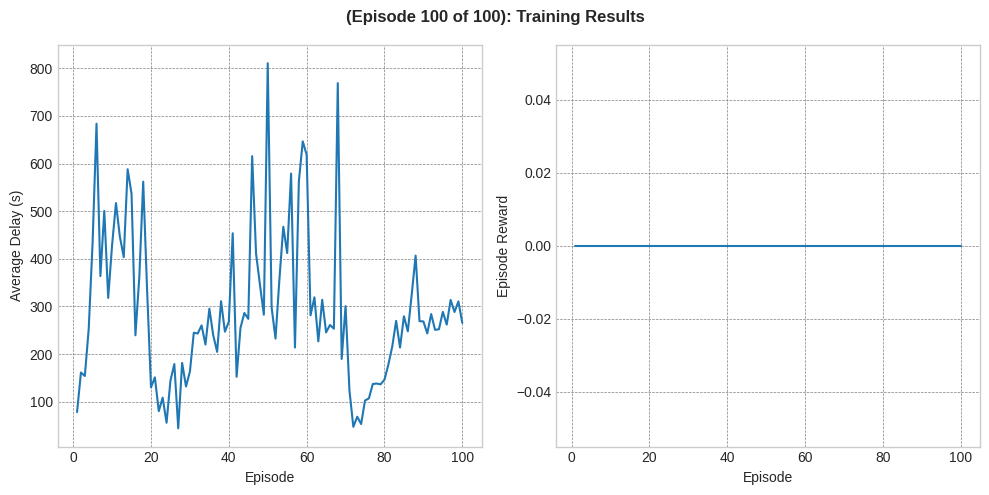

In [9]:
log_rewards, log_states = [], []
log_epi_average_delay = []

steps_done = 0
num_episodes = 100

for i_episode in range(num_episodes):
    # Initialize the environment and get the initial state
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    log_rewards.append([])
    log_states.append([])
    for t in count():
        action = select_action(state)
        observation, reward, terminated, truncated, _ = env.step(action.item())
        reward = torch.tensor([reward], device=device)
        done = terminated or truncated

        if terminated:
            next_state = None
        else:
            next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

        log_states[-1].append(state)

        # Store the transition in memory
        memory.push(state, action, next_state, reward)

        # Move to the next state
        state = next_state

        # Perform one step of the optimization (on the policy network)
        optimize_model()

        # Soft update of the target network's weights
        # θ′ ← τ θ + (1 −τ )θ′
        target_net_state_dict = target_net.state_dict()
        policy_net_state_dict = policy_net.state_dict()
        for key in policy_net_state_dict:
            target_net_state_dict[key] = policy_net_state_dict[key]*TAU + target_net_state_dict[key]*(1-TAU)
        target_net.load_state_dict(target_net_state_dict)

        if done:
            log_epi_average_delay.append(env.W.analyzer.average_delay)
            break

    # Visualise Training
    clear_output(wait=True)
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, (d_ax, r_ax) = plt.subplots(1, 2, figsize=(10, 5))
    d_ax.plot(range(1, len(log_epi_average_delay) + 1), log_epi_average_delay)
    d_ax.set_ylabel("Average Delay (s)")
    r_ax.plot(range(1, len(log_rewards) + 1), [sum(ep_data) for ep_data in log_rewards])
    r_ax.set_ylabel("Episode Reward")
    for ax in (d_ax, r_ax):
        ax.set_xlabel("Episode")
        ax.grid(True, 'both', color='grey', linestyle='dashed', linewidth=0.5)
    fig.suptitle(f"(Episode {i_episode+1} of {num_episodes}): Training Results", fontweight="bold")
    fig.tight_layout()
    plt.show()


## Run Final Evaluation

In [10]:
steps_done, seed = 0, 1
g_times = [0, 0, 0, 0]

state, info = env.reset()
state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
for t in count():
    action = select_action(state)
    observation, reward, terminated, truncated, _ = env.step(action.item())
    done = terminated or truncated

    g_times[action.item()] += control_interval

    if terminated: next_state = None
    else: next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)
    state = next_state

    if done: break

env.W.analyzer.print_simple_stats(force_print=True)

results:
 average speed:	 4.6 m/s
 number of completed trips:	 2195 / 2420
 total travel time:		 469525.0 s
 average travel time of trips:	 213.9 s
 average delay of trips:	 113.9 s
 delay ratio:			 0.533
 total distance traveled:	 2338750.0 m


## Visualise Results

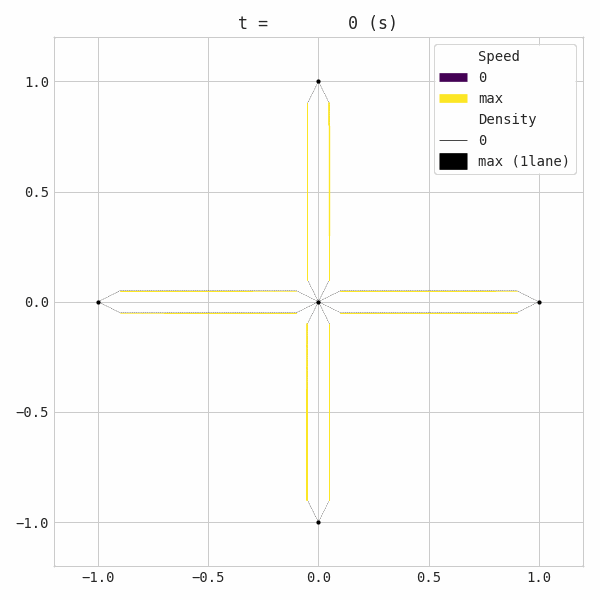

In [11]:
gif_loc = "final_eval.gif"
env.W.analyzer.network_anim(detailed=1, figsize=(6,6), network_font_size=0, file_name=gif_loc)

from IPython.display import display, Image
with open(gif_loc, "rb") as f: display(Image(data=f.read(), format='png'))

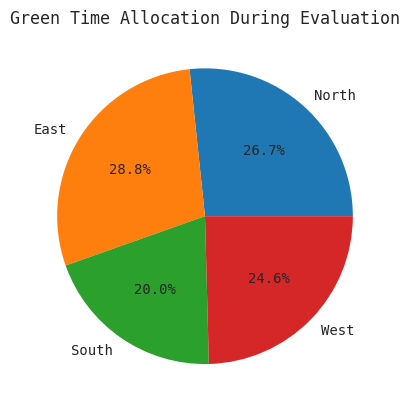

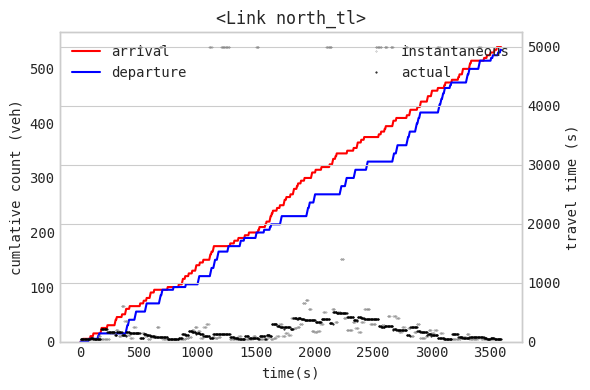

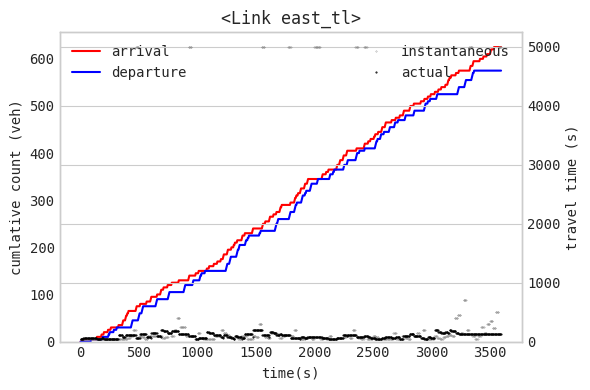

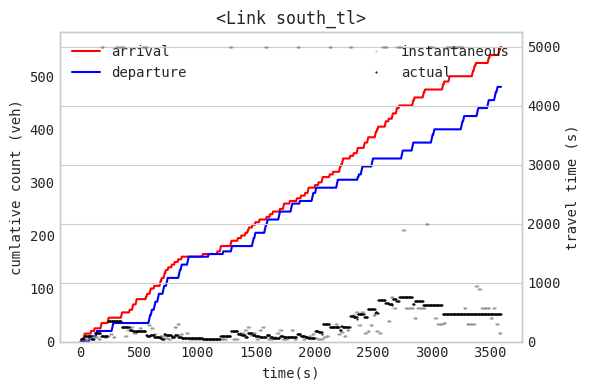

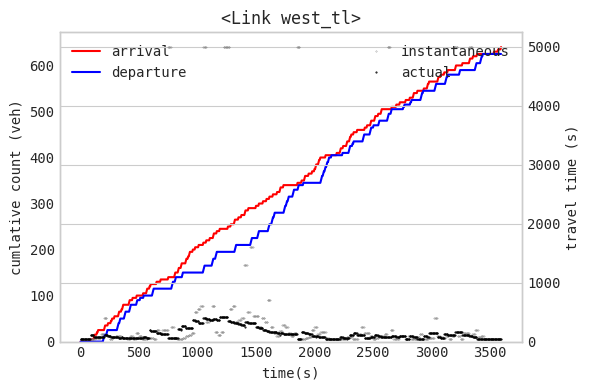

In [12]:
nodes = ['north', 'east', 'south', 'west']

fig, ax = plt.subplots()
ax.pie(g_times, labels=[n.title() for n in nodes], autopct='%1.1f%%')
ax.set_title("Green Time Allocation During Evaluation")

env.W.analyzer.cumulative_curves([f"{org}_tl" for org in nodes])